Step 1: Install Required Libraries

In [1]:
pip install openai pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


Step 2: Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI

Step 3: Create or Load Dataset

In [3]:
data = {
    "review": [
        "The product quality is amazing!",
        "Delivery was very slow",
        "Customer support helped me quickly",
        "Very bad experience",
        "Excellent service and fast shipping",
        "The packaging was damaged",
        "Great product value"
    ]
}

df = pd.DataFrame(data)

Step 4: Connect to OpenAI API

In [4]:
client = OpenAI()

Step 5: Sentiment Analysis Function

In [5]:
def get_sentiment(review):

    prompt = f"""
    Classify the sentiment of the review as:
    Positive, Negative, or Neutral.

    Review: {review}
    """

    response = client.responses.create(
        model="gpt-4.1-mini",
        input=prompt
    )

    return response.output_text.strip()

Step 6: Apply AI Sentiment Analysis

In [6]:
df["sentiment"] = df["review"].apply(get_sentiment)

print(df)

                                review  \
0      The product quality is amazing!   
1               Delivery was very slow   
2   Customer support helped me quickly   
3                  Very bad experience   
4  Excellent service and fast shipping   
5            The packaging was damaged   
6                  Great product value   

                                           sentiment  
0  The sentiment of the review "The product quali...  
1  The sentiment of the review "Delivery was very...  
2  The sentiment of the review "Customer support ...  
3  The sentiment of the review "Very bad experien...  
4           The sentiment of the review is Positive.  
5  The sentiment of the review "The packaging was...  
6  The sentiment of the review "Great product val...  


Step 7: Aggregate Results

In [7]:
sentiment_counts = df["sentiment"].value_counts()

print(sentiment_counts)

sentiment
The sentiment of the review "The product quality is amazing!" is Positive.       1
The sentiment of the review "Delivery was very slow" is Negative.                1
The sentiment of the review "Customer support helped me quickly" is Positive.    1
The sentiment of the review "Very bad experience" is Negative.                   1
The sentiment of the review is Positive.                                         1
The sentiment of the review "The packaging was damaged" is Negative.             1
The sentiment of the review "Great product value" is Positive.                   1
Name: count, dtype: int64


Step 8: Visualization (Sentiment Chart)

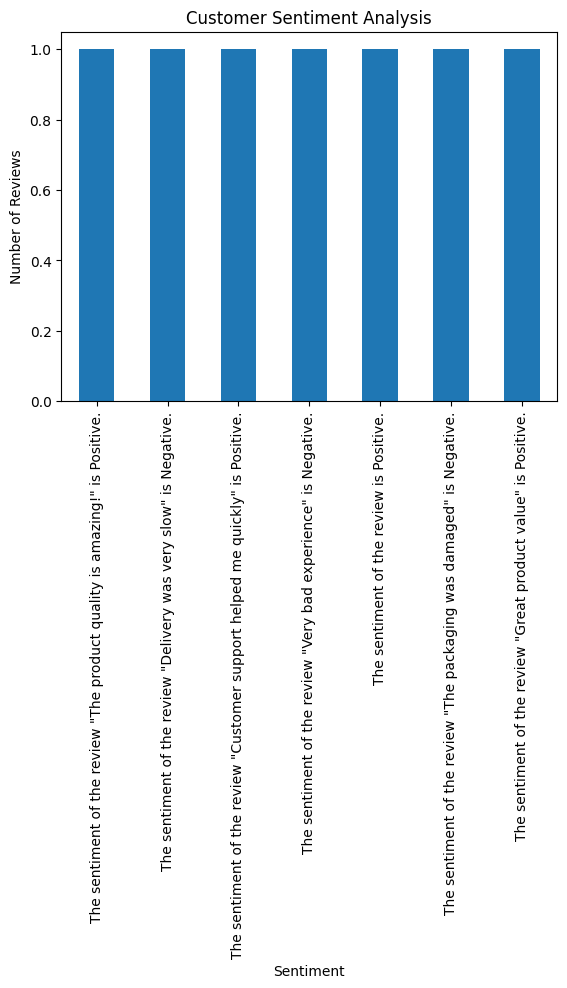

In [8]:
plt.figure()
sentiment_counts.plot(kind="bar")

plt.title("Customer Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

Step 9: AI Insight Generation

In [9]:
reviews_text = " ".join(df["review"])

response = client.responses.create(
    model="gpt-4.1-mini",
    input=f"Analyze these reviews and provide key customer insights: {reviews_text}"
)

print(response.output_text)

Based on the reviews provided, here are the key customer insights:

1. **Product Quality**: Customers generally find the product quality to be excellent ("The product quality is amazing!", "Great product value").
2. **Shipping and Delivery**: Shipping speed and condition are inconsistent; some customers mention slow delivery ("Delivery was very slow") and damaged packaging ("The packaging was damaged"), while others praise fast shipping ("Excellent service and fast shipping").
3. **Customer Support**: When needed, customer support is responsive and helpful ("Customer support helped me quickly").
4. **Overall Experience**: Customer experiences vary widely, with some reporting very bad experiences ("Very bad experience") and others very positive feedback ("Excellent service").

**Summary:** Customers appreciate the product quality and customer support but have concerns about shipping speed and package condition, leading to mixed overall experiences. Improving delivery reliability and pac